In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
calendar = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Calendar.csv")
customers = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Customers.csv")
products = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Products.csv")
regions = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Regions.csv")
returns = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Returns_1997-1998.csv")
stores = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Stores.csv")
transactions_1997 = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Transactions_1997.csv")
transactions_1998 = pd.read_csv("C:\\Users\\rauty\\Downloads\\Retail-Business-Analytics\\data\\MavenMarket_Transactions_1998.csv")


In [3]:
transactions = pd.concat(
    [transactions_1997, transactions_1998],
    ignore_index=True
)

In [4]:
print(transactions.shape)
print(products.shape)
print(customers.shape)
print(stores.shape)
print(returns.shape)

(269720, 6)
(1560, 9)
(10281, 20)
(24, 13)
(7087, 4)


In [5]:
#Merge into One Master Dataset

In [6]:
master = transactions.merge(
    products,
    on="product_id",
    how="left"
)

master.head()

,transaction_date,stock_date,product_id,customer_id,store_id,quantity,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat
0,1/1/1997,12/31/1996,869,3449,6,5,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.12,0.91,17.00,1.0,NaN
1,1/1/1997,12/31/1996,1472,3449,6,3,Fort West,Fort West Fudge Cookies,37276054024,2.20,0.90,8.28,1.0,NaN
2,1/1/1997,12/28/1996,76,3449,6,4,Red Spade,Red Spade Sliced Chicken,62054644227,1.69,0.69,18.10,NaN,1.0
3,1/1/1997,12/26/1996,320,3449,6,3,Excellent,Excellent Cranberry Juice,36570182442,3.26,1.08,16.40,NaN,NaN
4,1/1/1997,12/25/1996,4,3449,6,4,Washington,Washington Cream Soda,64412155747,3.64,1.64,10.60,1.0,NaN


In [7]:
master = master.merge(
    customers,
    on="customer_id",
    how="left"
)

In [8]:
master = master.merge(
    stores,
    on="store_id",
    how="left"
)

In [9]:
master = master.merge(
    regions,
    on="region_id",
    how="left"
)

In [10]:
master["Sales"] = master["quantity"] * master["product_retail_price"]

master["Profit"] = (
    master["product_retail_price"] - master["product_cost"]
) * master["quantity"]

In [11]:
master["transaction_date"] = pd.to_datetime(master["transaction_date"])

In [12]:
master.shape

(269720, 49)

In [13]:
##Sales Trend Analysis 

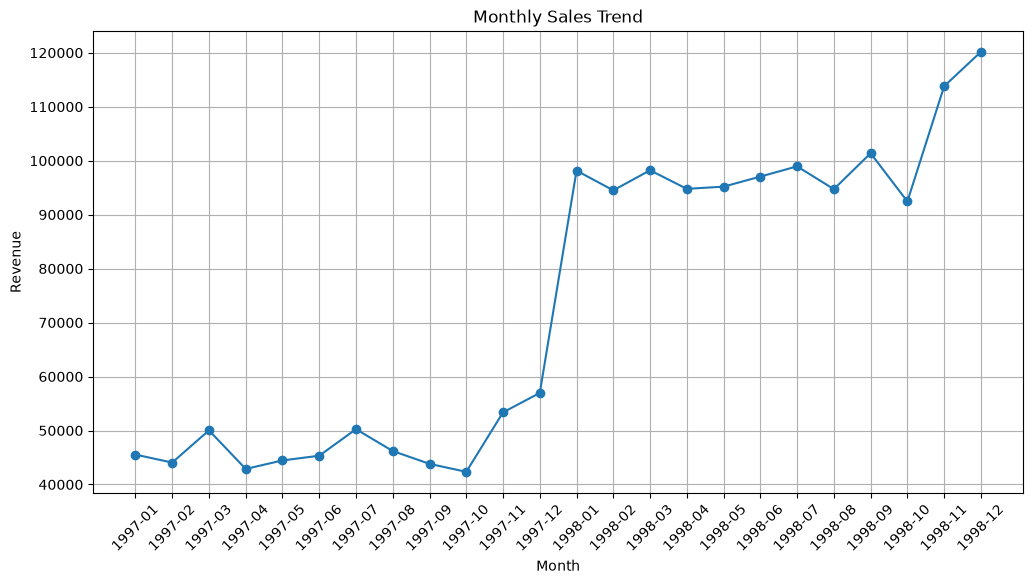

In [14]:
master['transaction_date'] = pd.to_datetime(master['transaction_date'])

monthly_sales = (
    master.groupby(master['transaction_date'].dt.to_period('M'))['Sales']
    .sum()
    .reset_index()
)

monthly_sales['transaction_date'] = monthly_sales['transaction_date'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['transaction_date'], monthly_sales['Sales'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [15]:
##Top 10 Products

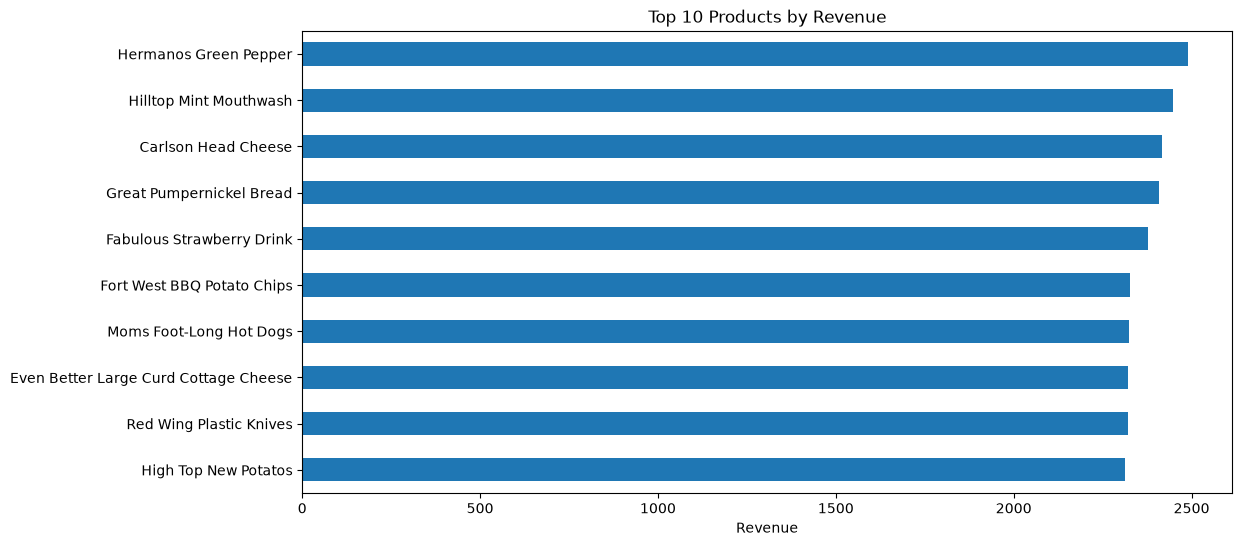

In [16]:
top_products = (
    master.groupby('product_name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_products.sort_values().plot(kind='barh')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("")
plt.show()

In [17]:
##Top 10 Stores

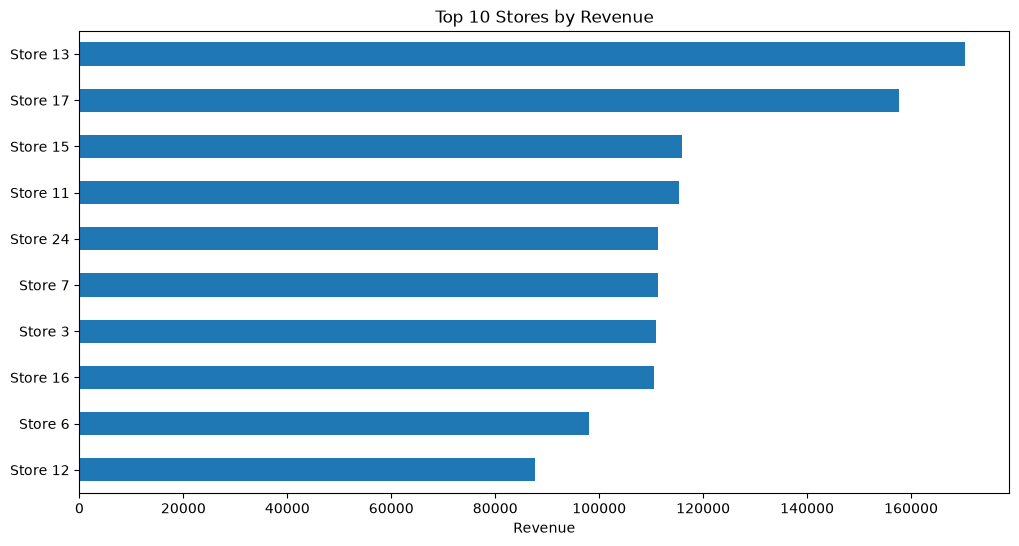

In [18]:
top_stores = (
    master.groupby('store_name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_stores.sort_values().plot(kind='barh')
plt.title("Top 10 Stores by Revenue")
plt.xlabel("Revenue")
plt.ylabel("")
plt.show()

In [19]:
# Revenue by Region

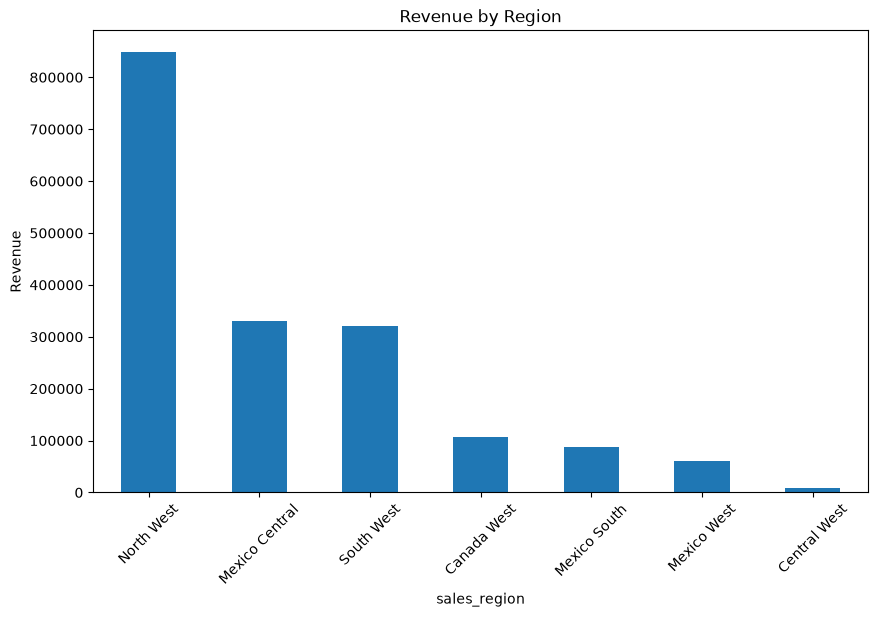

In [20]:
region_sales = (
    master.groupby('sales_region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
region_sales.plot(kind='bar')
plt.title("Revenue by Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [21]:
# Profit Distribution

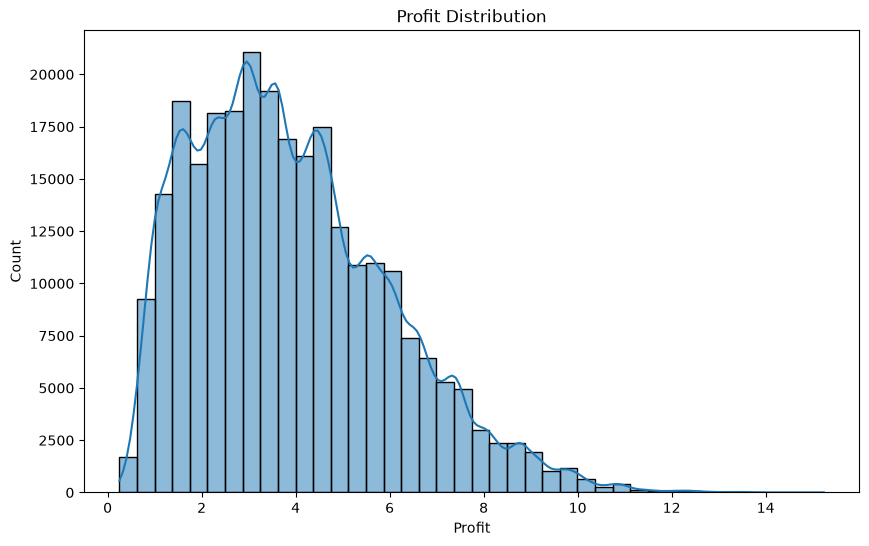

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(master['Profit'], bins=40, kde=True)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.show()

In [23]:
# Sales vs Profit

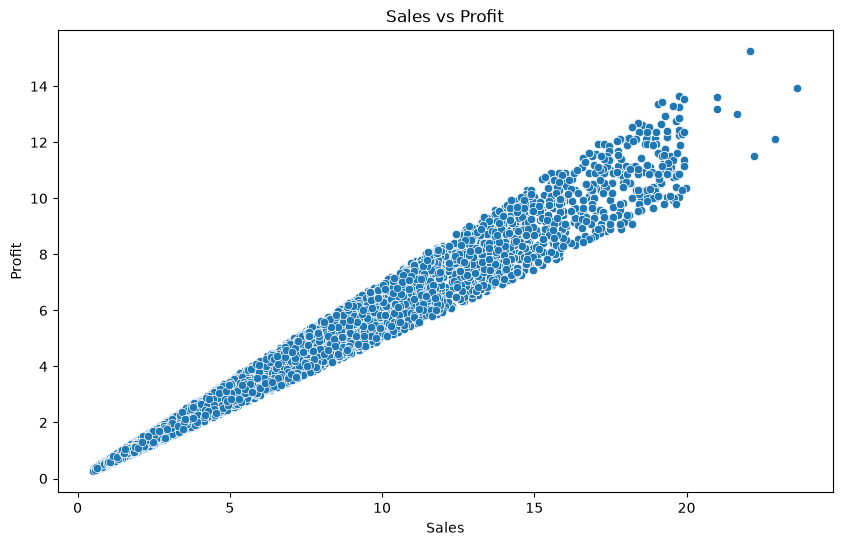

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=master,
    x='Sales',
    y='Profit'
)

plt.title("Sales vs Profit")
plt.show()

In [25]:
# Revenue by Brand

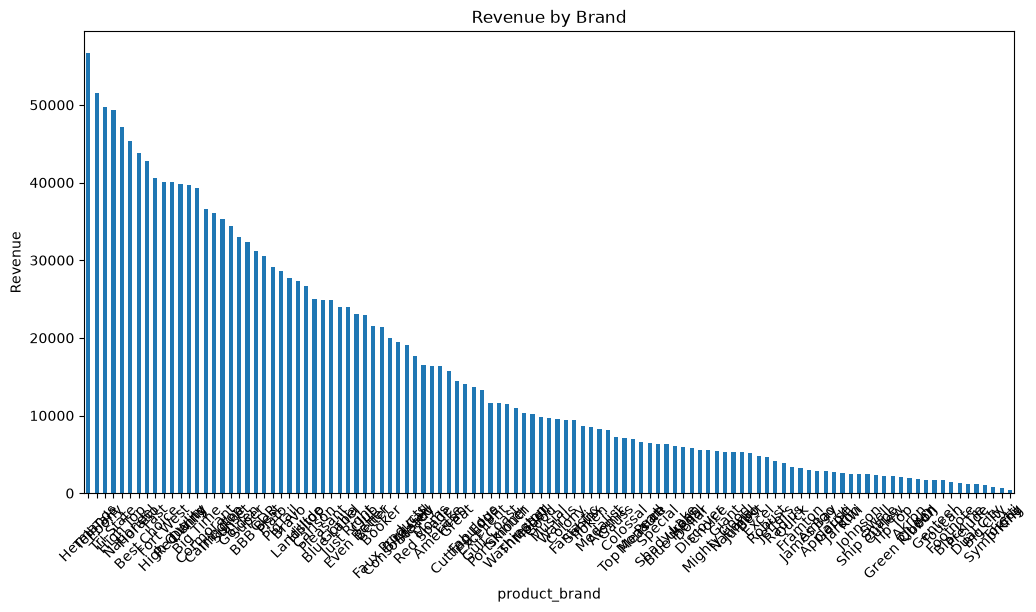

In [26]:
brand_sales = (
    master.groupby('product_brand')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
brand_sales.plot(kind='bar')
plt.title("Revenue by Brand")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [27]:
# Interactive Sales Trend (Plotly)

In [28]:
fig = px.line(
    monthly_sales,
    x='transaction_date',
    y='Sales',
    title='Monthly Sales Trend'
)

fig.show()

In [ ]:
# Business Analytics
# Pareto Analysis (80/20 Rule)
# High Revenue but Low Margin Products
# Region Performance Matrix
# Store Performance
# Customer Segmentation
# Return Analysis

In [ ]:
# Pareto Analysis (80/20 Rule)
product_sales = (
    master.groupby("product_name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_sales["Revenue_%"] = (
    product_sales["Sales"] /
    product_sales["Sales"].sum()
) * 100

product_sales["Cumulative_%"] = (
    product_sales["Revenue_%"].cumsum()
)

product_sales.head()

,product_name,Sales,Revenue_%,Cumulative_%
0,Hermanos Green Pepper,2489.70,0.141096,0.141096
1,Hilltop Mint Mouthwash,2447.12,0.138683,0.279778
2,Carlson Head Cheese,2417.73,0.137017,0.416795
3,Great Pumpernickel Bread,2408.56,0.136497,0.553293
4,Fabulous Strawberry Drink,2377.90,0.134760,0.688053


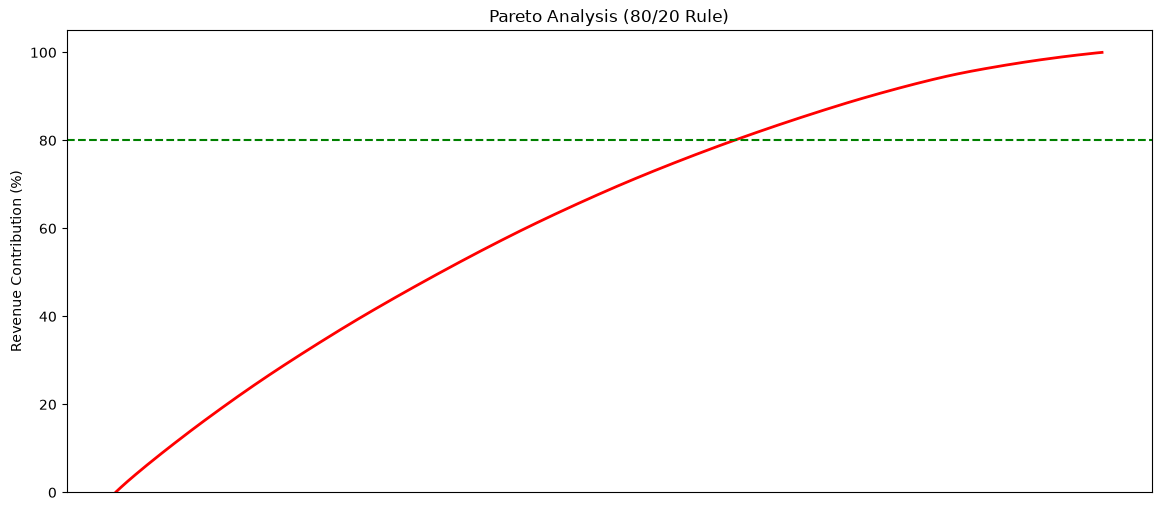

In [32]:
plt.figure(figsize=(14,6))

plt.bar(
    product_sales["product_name"],
    product_sales["Revenue_%"]
)

plt.plot(
    product_sales["Cumulative_%"],
    color="red",
    linewidth=2
)

plt.axhline(80, color="green", linestyle="--")

plt.xticks([], [])

plt.title("Pareto Analysis (80/20 Rule)")

plt.ylabel("Revenue Contribution (%)")

plt.show()

In [ ]:
# High Revenue but Low Margin Products
product_analysis = (
    master.groupby("product_name")
    .agg(
        Revenue=("Sales","sum"),
        Profit=("Profit","sum")
    )
)

product_analysis["Margin"] = (
    product_analysis["Profit"] /
    product_analysis["Revenue"]
) * 100

product_analysis.sort_values(
    "Revenue",
    ascending=False
).head(20)

,Revenue,Profit,Margin
product_name,,,
Hermanos Green Pepper,2489.70,1670.55,67.098446
Hilltop Mint Mouthwash,2447.12,1493.96,61.049724
Carlson Head Cheese,2417.73,1254.54,51.889169
Great Pumpernickel Bread,2408.56,1326.64,55.080214
Fabulous Strawberry Drink,2377.90,1474.90,62.025316
Fort West BBQ Potato Chips,2328.00,1326.00,56.958763
Moms Foot-Long Hot Dogs,2325.40,1183.84,50.909091
Even Better Large Curd Cottage Cheese,2322.60,1275.96,54.936709
Red Wing Plastic Knives,2321.25,1343.23,57.866667


In [ ]:
# Region Performance Matrix
region_analysis = (
    master.groupby("sales_region")
    .agg(
        Revenue=("Sales","sum"),
        Profit=("Profit","sum")
    )
)

region_analysis

,Revenue,Profit
sales_region,,
Canada West,107674.34,64341.00
Central West,9324.94,5569.91
Mexico Central,330362.03,197072.61
Mexico South,87253.65,51991.14
Mexico West,61299.98,36623.57
North West,847826.72,505783.29
South West,320804.78,191437.26


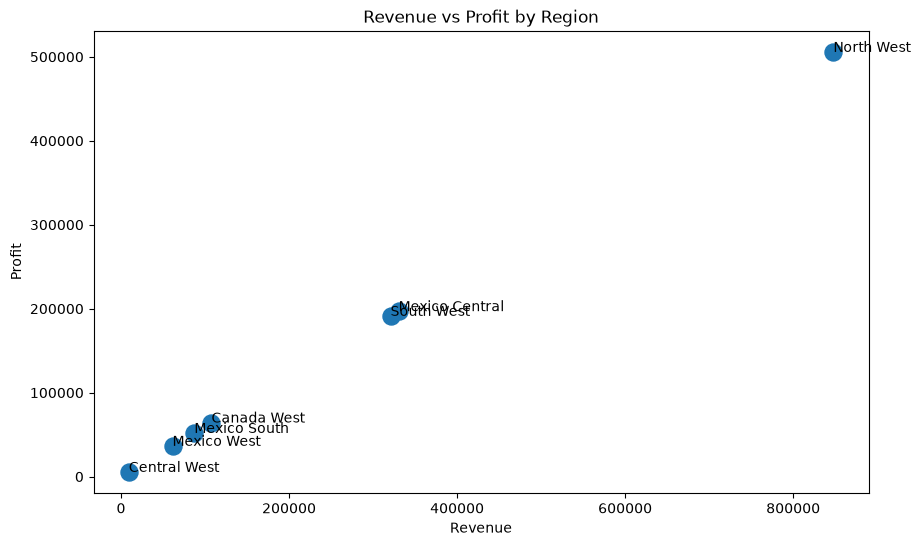

In [38]:
plt.figure(figsize=(10,6))

plt.scatter(
    region_analysis["Revenue"],
    region_analysis["Profit"],
    s=150
)

for region in region_analysis.index:
    plt.text(
        region_analysis.loc[region,"Revenue"],
        region_analysis.loc[region,"Profit"],
        region
    )

plt.xlabel("Revenue")

plt.ylabel("Profit")

plt.title("Revenue vs Profit by Region")

plt.show()

In [ ]:
# Store Ranking
store_analysis = (
    master.groupby("store_name")
    .agg(
        Revenue=("Sales","sum"),
        Profit=("Profit","sum")
    )
    .sort_values("Revenue",ascending=False)
)

store_analysis.head(10)

,Revenue,Profit
store_name,,
Store 13,170398.94,101714.65
Store 17,157695.90,94087.96
Store 15,115981.46,69148.47
Store 11,115334.62,68857.27
Store 24,111378.46,66459.56
Store 7,111311.54,66424.49
Store 3,110877.88,66055.01
Store 16,110485.16,65911.35
Store 6,98114.78,58553.21


In [ ]:
# Customer Segmentation
customer_analysis = (
    master.groupby("customer_id")
    .agg(
        Revenue=("Sales","sum"),
        Orders=("transaction_date","count")
    )
)

customer_analysis["Segment"] = "Bronze"

customer_analysis.loc[
    customer_analysis["Revenue"] >= 5000,
    "Segment"
] = "Gold"

customer_analysis.loc[
    (customer_analysis["Revenue"] >= 2500) &
    (customer_analysis["Revenue"] < 5000),
    "Segment"
] = "Silver"

customer_analysis.head()

,Revenue,Orders,Segment
customer_id,,,
3,203.17,30,Bronze
5,1.08,1,Bronze
6,147.71,16,Bronze
8,259.14,42,Bronze
9,89.58,13,Bronze


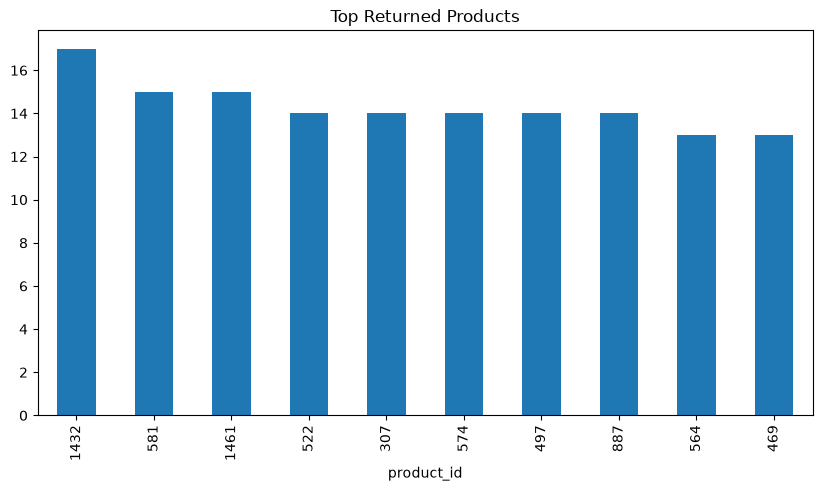

In [41]:
# Returns Analysis
top_returns = (
    returns.groupby("product_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_returns.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Returned Products")

plt.show()